In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from scipy.optimize import fsolve
from scipy import stats
import statsmodels.api as sm
from scipy.stats import norm
from scipy.optimize import root

import warnings

warnings.filterwarnings(
    "ignore",
    message="Maximum Likelihood optimization failed to.*"
)

### Задание 6. Модели MA ###

#### *1. Временной ряд описывается моделью скользящего среднего $y_t = ε_t + 0.2 ε_{t−1} − 0.1 ε_{t−2}$.* ####

- Определите, будет ли этот ряд стационарным

Процесс MA(q) всегда стационарен!

- Определите, будет ли этот ряд обратимым.

Полином скользящего среднего: 
$$ 1+0.2L−0.1L^2$$

решается уравнение $ 1+0.2L−0.1L^2 = 0$. Корни:

$$ z = 1 \pm \sqrt{1+10} \approx 1 \pm 3.317 \Rightarrow z_1 = 4.317,~z_2 = -2.317$$

Оба $|z_i| > 1$, значит процесс обратим.

- Вычислите автокорреляционную функцию модели и постройте ее график

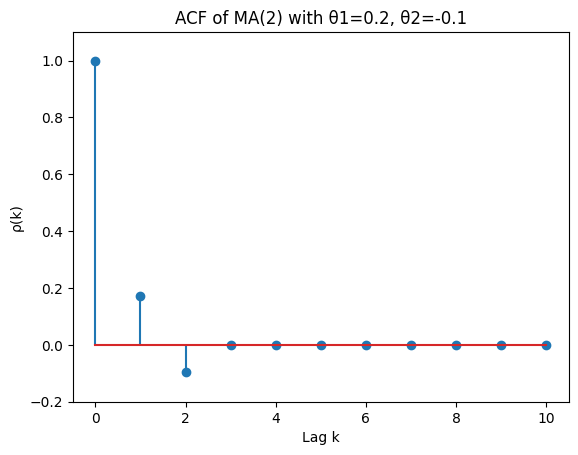

In [38]:
theta1 = 0.2
theta2 = -0.1
sigma2 = 1.0 

# Compute autocorrelations for lags 0 through 10
lags = np.arange(11)
gamma0 = sigma2 * (1 + theta1**2 + theta2**2)
gamma1 = sigma2 * (theta1 + theta1*theta2)
gamma2 = sigma2 * theta2
rhos = np.zeros_like(lags, dtype=float)
rhos[0] = 1
rhos[1] = gamma1 / gamma0
rhos[2] = gamma2 / gamma0

plt.figure()
markerline, stemlines, baseline = plt.stem(lags, rhos)
plt.xlabel('Lag k')
plt.ylabel('ρ(k)')
plt.title('ACF of MA(2) with θ1=0.2, θ2=-0.1')
plt.ylim(-0.2, 1.1)
plt.show()


#### *2. По серии измерений давления P в абсорбере вычислите разности давлений ∆P. Постройте модель скользящего среднего MA(q). Для этого:* ####


- постройте графики выборочных ACF и PACF для ∆P, оцените порядок модели q;

In [39]:
df = pd.read_excel("TimeSeries.xls", header=None)[2:].astype(float)
P = df.iloc[:, 0].values.flatten()[1:]
time = np.arange(len(P)) * 4

dP = np.diff(P)

Определён порядок MA(q): q = 2


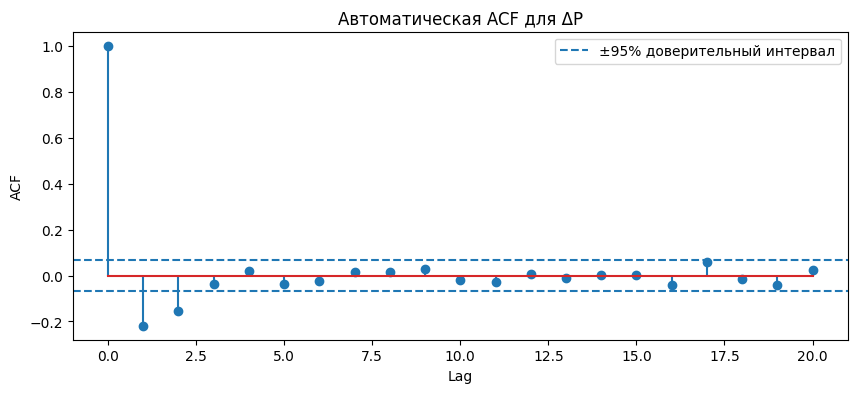

In [40]:
n = len(dP)
max_lag = 20
acf_vals = acf(dP, nlags=max_lag, fft=False)
threshold = 1.96 / np.sqrt(n)

significant_lags = np.where(np.abs(acf_vals[1:]) > threshold)[0] + 1
q = int(significant_lags.max()) if significant_lags.size > 0 else 0

print(f"Определён порядок MA(q): q = {q}")

plt.figure(figsize=(10, 4))
plt.stem(range(len(acf_vals)), acf_vals)
plt.axhline(threshold, linestyle='--', label='±95% доверительный интервал')
plt.axhline(-threshold, linestyle='--')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.title('Автоматическая ACF для ΔP')
plt.legend()
plt.show()

- оцените коэффициенты модели методом моментов и вычислите остатки;

Пусть $\{\Delta P_t\}_{t=1}^N$ — приращения давления. Оценим параметры $\theta_1,\dots,\theta_q$ в модели
$$
\Delta P_t = \varepsilon_t + \theta_1\,\varepsilon_{t-1} + \dots + \theta_q\,\varepsilon_{t-q},
$$
где $\{\varepsilon_t\}$ — белый шум с $E[\varepsilon_t]=0$ и $\mathrm{Var}(\varepsilon_t)=\sigma^2$, причём по лекции $\theta_0=1$.

1. **Выборочные автокорреляции.**  
   По лекции:
   $$
   r_k
   = \frac{\displaystyle \sum_{t=k+1}^{N} \Delta P_t\,\Delta P_{t-k}}
          {\displaystyle \sum_{t=1}^{N} (\Delta P_t)^2},
   \quad k=1,2,\dots,q.
   $$

2. **Теоретические автокорреляции MA(q).**  
   Теоретические автоковариации:
   $$
   \gamma_k
   = \mathrm{Cov}(\Delta P_t,\Delta P_{t-k})
   = \sigma^2 \sum_{i=0}^{q-k} \theta_i\,\theta_{i+k},
   \quad k=0,1,\dots,q,
   $$
   где $\theta_0=1$. Тогда
   $$
   \rho_k
   = \frac{\gamma_k}{\gamma_0}
   = \frac{\sum_{i=0}^{q-k} \theta_i\,\theta_{i+k}}
          {\sum_{i=0}^{q} \theta_i^2},
   \quad k=1,\dots,q.
   $$

3. **Система уравнений метода моментов.**  
   Приравниваем первые $q$ выборочных автокорреляций к теоретическим:
   $$
   \rho_k(\theta_1,\dots,\theta_q) = r_k,
   \quad k=1,\dots,q.
   $$
   Получаем $q$ нелинейных уравнений по $\theta_1,\dots,\theta_q$.

4. **Численное решение.**  
   - Начальное приближение: $\theta_i^{(0)} = 0$.  
   - Решение системы методом Ньютона (SciPy: `fsolve`).  
   - Проверка обратимости: корни многочлена  
     $\Theta(z)=\sum_{i=0}^q \theta_i\,z^i$  
     должны лежать вне единичного круга $\{|z|>1\}$.

5. **Оценка дисперсии шума $\sigma^2$.**  
   $$
   \hat\sigma^2
   = \frac{1}{N}\sum_{t=1}^N 
     \Bigl(\Delta P_t - \sum_{i=1}^q \hat\theta_i\,\varepsilon_{t-i}\Bigr)^{2},
   $$
   где $\{\varepsilon_t\}$ — восстановленные остатки.

6. **Восстановление остатков.**  
   По инвертированному MA-фильтру:
   $$
   \hat\varepsilon_t
   = \Delta P_t - \sum_{i=1}^q \hat\theta_i\,\hat\varepsilon_{t-i},
   \quad \hat\varepsilon_t=0\ (\!t\le0\!).
   $$


Оценки θ: [-0.29434399 -0.17160402]


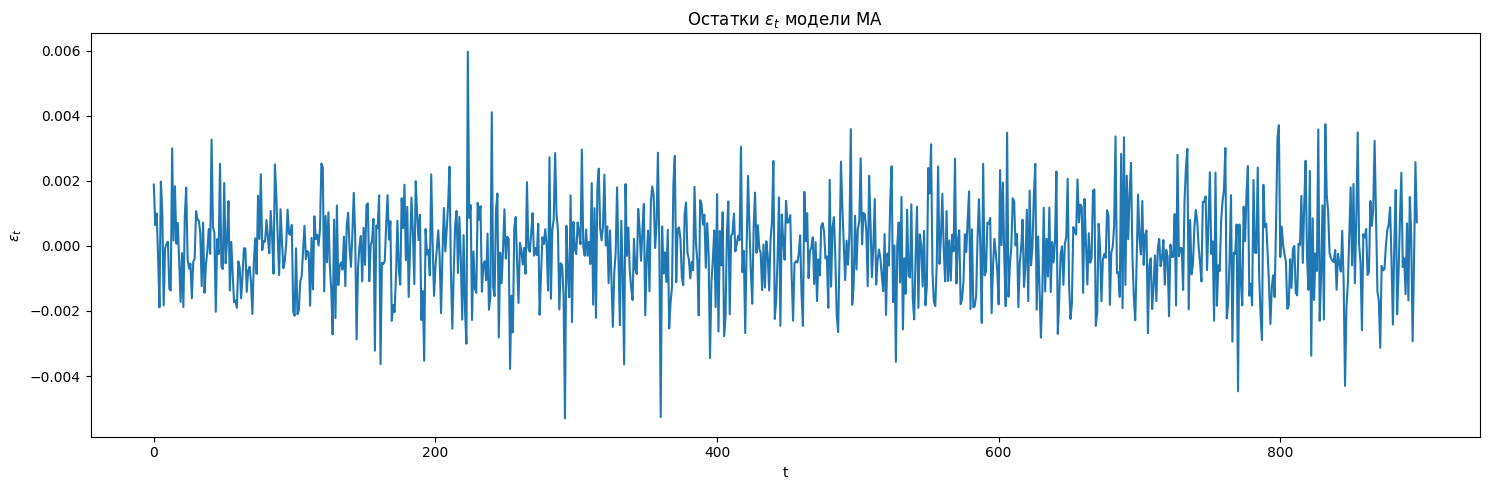

In [41]:
sample_rho = acf_vals[1:q+1]

def theoretical_rhos(theta):
    th = np.concatenate([[1.0], theta])
    gamma0 = np.sum(th**2)
    rhos = []
    for k in range(1, len(th)):
        gamma_k = np.sum(th[:-k] * th[k:])
        rhos.append(gamma_k / gamma0)
    return np.array(rhos)

def equations(theta):
    return theoretical_rhos(theta) - sample_rho

if q > 0:
    init = np.zeros(q)
    theta_est = fsolve(equations, init)
    print(f"Оценки θ: {theta_est}")

    eps = np.zeros(n)
    for t in range(n):
        val = dP[t]
        for i in range(1, q+1):
            if t - i >= 0:
                val -= theta_est[i-1] * eps[t-i]
        eps[t] = val

    res_df = pd.DataFrame({
        'ΔP': dP,
        'ε (остаток)': eps
    })

    # b) График остатков
    plt.figure(figsize=(15, 5))
    plt.plot(eps)
    plt.title('Остатки $ε_t$ модели MA')
    plt.xlabel('t')
    plt.ylabel('$ε_t$')
    plt.tight_layout()
    plt.show()
else:
    print("Нулевой порядок: модель MA(0) (остатки — сам ряд белого шума).")

- оцените коэффициенты модели методом наименьших квадратов, проверьте их значимость с помощью критериев Стьюдента и Фишера; подберите порядок модели q на основе последнего значимого коэффициента;


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  898
Model:                ARIMA(0, 0, 10)   Log Likelihood                4620.937
Date:                Sat, 03 May 2025   AIC                          -9219.874
Time:                        11:19:35   BIC                          -9167.073
Sample:                             0   HQIC                         -9199.702
                                - 898                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3063      0.033     -9.251      0.000      -0.371      -0.241
ma.L2         -0.1831      0.037     -4.918      0.000      -0.256      -0.110
ma.L3         -0.0471      0.036     -1.317      0.1

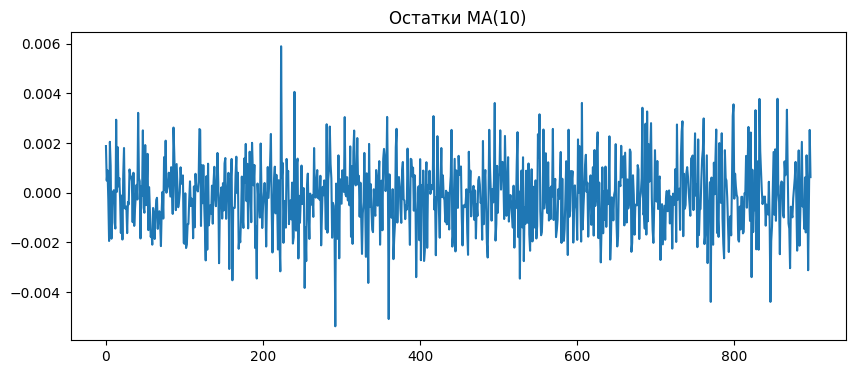

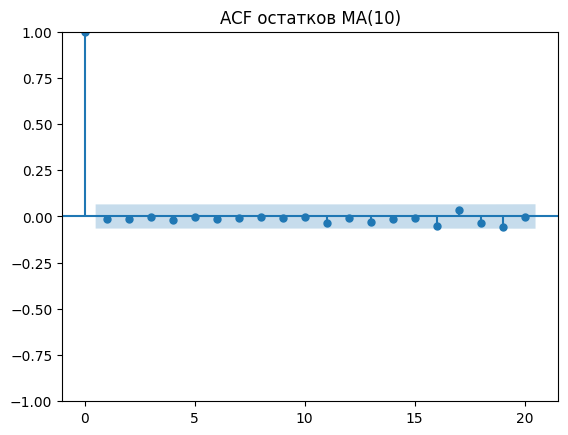

In [42]:
model10 = ARIMA(dP, order=(0, 0, 10), trend='n')
res10 = model10.fit()

print(res10.summary())

plt.figure(figsize=(10,4))
plt.plot(res10.resid)
plt.title('Остатки MA(10)')
plt.show()

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(res10.resid, lags=20, title="ACF остатков MA(10)")
plt.show()

In [43]:
res2  = ARIMA(dP, order=(0,0,2),  trend='n').fit()
res10 = ARIMA(dP, order=(0,0,10), trend='n').fit()

SSR2  = np.sum(res2.resid**2)
SSR10 = np.sum(res10.resid**2)

p  = 10 - 2          # число “дополнительных” параметров в MA(10) vs MA(2)
df1 = p              # numerator degrees of freedom
df2 = n - 10         # denominator degrees of freedom

F_stat = ((SSR2 - SSR10) / df1) / (SSR10 / df2)
p_value = 1 - stats.f.cdf(F_stat, df1, df2)

print(f"SSR₂ (q=2):   {SSR2:.4f}")
print(f"SSR₁₀ (q=10): {SSR10:.4f}\n")
print(f"F = {F_stat:.3f}, df1 = {df1}, df2 = {df2}")
print(f"p-value = {p_value:.4f}")

if p_value < 0.05:
    print("→ Разница значима (отклоняем H₀: MA(2) достаточной).")
else:
    print("→ Нет оснований отвергать H₀: MA(2) достаточно.")

SSR₂ (q=2):   0.0018
SSR₁₀ (q=10): 0.0018

F = 0.688, df1 = 8, df2 = 888
p-value = 0.7022
→ Нет оснований отвергать H₀: MA(2) достаточно.


- опираясь на графики ACF остатков модели MA(q), подберите наименьший допустимый порядок q;

MA(1): значимые автокорреляции в остатках на лагах [2, 3]


<Figure size 800x400 with 0 Axes>

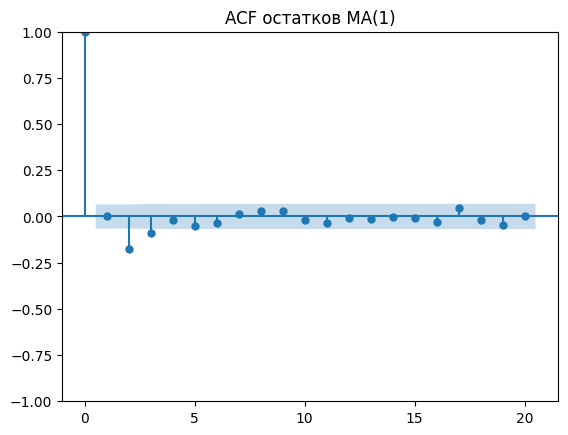

MA(2): значимые автокорреляции в остатках на лагах []

→ Минимальный допустимый порядок: q = 2



<Figure size 800x400 with 0 Axes>

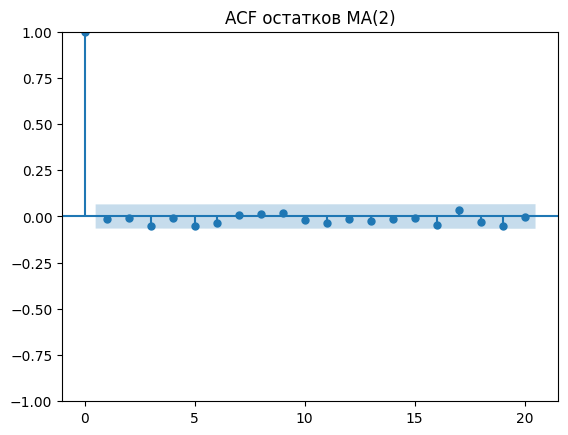

MA(3): значимые автокорреляции в остатках на лагах []


<Figure size 800x400 with 0 Axes>

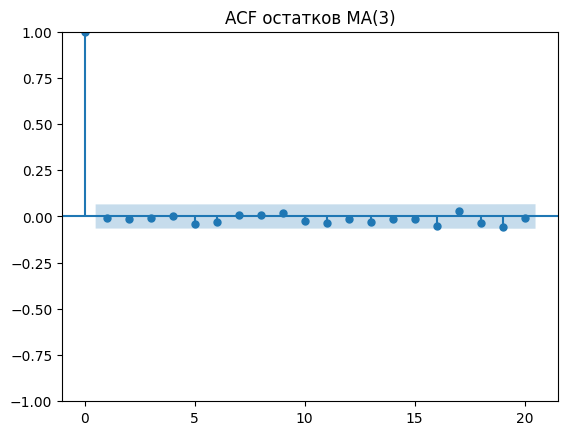

MA(4): значимые автокорреляции в остатках на лагах []


<Figure size 800x400 with 0 Axes>

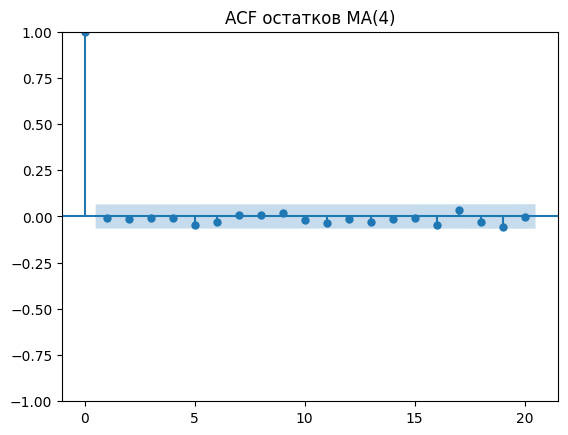

In [44]:
conf_bound = 1.96 / np.sqrt(n)
maxlag = 20   # до какого лага проверяем
flag = False

for q in range(1, 5):
    res = ARIMA(dP, order=(0, 0, q), trend='n').fit()
    resid = res.resid

    acf_vals = acf(resid, nlags=maxlag, fft=False)

    sig_lags = [lag for lag, rho in enumerate(acf_vals[1:], start=1) if abs(rho) > conf_bound]

    print(f"MA({q}): значимые автокорреляции в остатках на лагах {sig_lags}")

    if not sig_lags and not flag:
        print(f"\n→ Минимальный допустимый порядок: q = {q}\n")
        flag = True

    plt.figure(figsize=(8,4))
    plot_acf(resid, lags=maxlag, title=f"ACF остатков MA({q})")
    plt.show()


- дают ли три рассмотренных метода подбора порядка модели одинаковые результаты?

Да!

- постройте прогноз давления P с упреждением в 10 минут и доверительный интервал для него.

Ниже приведены основные шаги и формулы, используемые в коде:

1. Оценка параметров MA(2) по выборочной ACF.

    Пусть $dP_t = P_t - P_{t-1}$ — ряд разностей. Вычисляем выборочные автокорреляции  
    $$
      \hat\rho(1),\;\hat\rho(2)
    $$
    и решаем систему теоретических уравнений MA(2):
    $$
      \rho(1)=\frac{\theta_1 + \theta_1\,\theta_2}{1 + \theta_1^2 + \theta_2^2}
      \;=\;\hat\rho(1),
      \quad
      \rho(2)=\frac{\theta_2}{1 + \theta_1^2 + \theta_2^2}
      \;=\;\hat\rho(2).
    $$
    В коде эта система решается численно через scipy.optimize.root.

2. Восстановление и оценка дисперсии шумовой компоненты. 

    Остатки модели $\varepsilon_t$ вычисляются рекурсивно из уравнения
    $$
      dP_t = \varepsilon_t + \theta_1\,\varepsilon_{t-1} + \theta_2\,\varepsilon_{t-2}.
    $$
    Затем оцениваем шумовую дисперсию
    $$
      \hat\sigma^2
      = \frac{1}{N} \sum_{t=1}^N 
      \bigl(dP_t - \hat\theta_1\,\varepsilon_{t-1} - \hat\theta_2\,\varepsilon_{t-2}\bigr)^2.
    $$

3. Прогноз разностей.
    
    Для MA(2) на $j$-м шаге ($j=1,2,3,\dots$) справедливы:
    $$
      \widehat{\Delta P}_{T+1}
        = \hat\theta_1\,\varepsilon_T + \hat\theta_2\,\varepsilon_{T-1},
      \quad
      \widehat{\Delta P}_{T+2}
        = \hat\theta_2\,\varepsilon_T,
      \quad
      \widehat{\Delta P}_{T+j}=0\quad (j\ge3).
    $$
    Тогда прогноз уровня
    $$
      \widehat P_{T+j}
      = P_T \;+\;\sum_{k=1}^j \widehat{\Delta P}_{T+k}.
    $$

 4. Дисперсия и доверительный интервал прогноза.
    
    Известны дисперсии шагов прогноза для MA(2):
    $$
      \mathrm{Var}(\Delta P_{T+1}) = \sigma^2, 
      \quad
      \mathrm{Var}(\Delta P_{T+2}) = \sigma^2\bigl(1 + \theta_1^2\bigr),
      \quad
      \mathrm{Var}(\Delta P_{T+j\ge3}) = \sigma^2\bigl(1 + \theta_1^2 + \theta_2^2\bigr).
    $$
    Поскольку уровневой прогноз аккумулирует сумму разностей,  
    $$
      \mathrm{Var}\bigl(\widehat P_{T+h}\bigr)
      = \sum_{k=1}^h \mathrm{Var}\bigl(\Delta P_{T+k}\bigr).
    $$
    Тогда 95\%–доверительный интервал:
    $$
      \widehat P_{T+h}
      \pm
      1.96\,\sqrt{\mathrm{Var}\bigl(\widehat P_{T+h}\bigr)}.
    $$


Таким образом, мы:
- оценили $\theta_1,\theta_2$ методом моментов по ACF,  
- восстановили остатки и оценили $\sigma^2$,  
- построили $h$–шаговый прогноз $\widehat P_{T+1\ldots T+h}$,  
- рассчитали его дисперсию и 95\% доверительный интервал.  


MA(2)-оценка: θ1=-0.3040, θ2=-0.1723, σ²=0.0000
Прогноз от t=54.87 мин (то есть за 5 мин до конца):
  через 600 с (10.0 мин): 70.647
  95% ДИ: [70.611, 70.682]


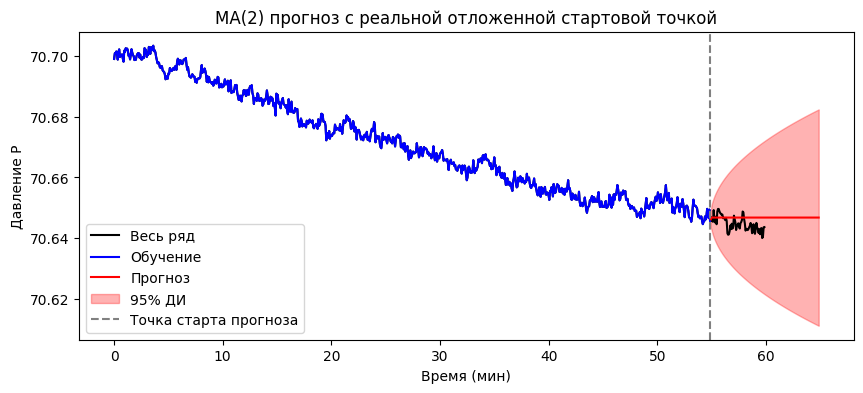

In [ ]:
df = pd.read_excel("TimeSeries.xls", header=None)[2:].astype(float)
P_full = df.iloc[:,0].values.flatten()[1:]
step_sec = 4
step_min = step_sec/60.0

lead_min = 5.0
m = int(lead_min*60/step_sec)         # число шагов = 5*60/4 = 75
P_train = P_full[:-m]                 # обучающая часть
time_full = np.arange(len(P_full))*step_min
time_train = time_full[:-m]

dP = np.diff(P_train)
n = len(dP)

def sample_acf(x, nlags):
    x = np.asarray(x)
    n = len(x); m = x.mean()
    acov = [np.sum((x[:n-k]-m)*(x[k:]-m))/n for k in range(nlags+1)]
    return np.array(acov)/acov[0]

rho1, rho2 = sample_acf(dP, 2)[1:3]
def eqs(th):
    t1, t2 = th
    D = 1 + t1**2 + t2**2
    return [(t1 + t1*t2)/D - rho1,
            t2/D - rho2]

t1, t2 = root(eqs, x0=[0.5,0.2]).x

eps = np.zeros(n)
for i in range(n):
    if i>=2: eps[i] = dP[i] - t1*eps[i-1] - t2*eps[i-2]
    elif i==1: eps[i] = dP[i] - t1*eps[i-1]
    else:      eps[i] = dP[i]

sigma2 = np.mean(eps**2)

H = int(np.ceil(600/step_sec))
dp_fc = np.zeros(H)
if H>=1: dp_fc[0] = t1*eps[-1] + t2*eps[-2]
if H>=2: dp_fc[1] = t2*eps[-1]
# далее — нули

# 7) Уровневой прогноз и доверительный интервал
P0 = P_train[-1]
P_fc = P0 + np.cumsum(dp_fc)
# дисперсии
var_dp = np.zeros(H)
for j in range(H):
    if j==0:       var_dp[j] = sigma2
    elif j==1:     var_dp[j] = sigma2*(1+t1**2)
    else:          var_dp[j] = sigma2*(1+t1**2+t2**2)
var_P = np.cumsum(var_dp)
z975 = norm.ppf(0.975)
ci_lo = P_fc - z975*np.sqrt(var_P)
ci_hi = P_fc + z975*np.sqrt(var_P)

# 8) Временные метки прогноза, начиная с time_train[-1]
t0 = time_train[-1]
t_fc = t0 + np.arange(1, H+1)*step_min

# 9) Вывод
print(f"MA(2)-оценка: θ1={t1:.4f}, θ2={t2:.4f}, σ²={sigma2:.4f}")
print(f"Прогноз от t={t0:.2f} мин (то есть за {lead_min:.0f} мин до конца):")
print(f"  через {H*step_sec} с ({H*step_sec/60:.1f} мин): {P_fc[-1]:.3f}")
print(f"  95% ДИ: [{ci_lo[-1]:.3f}, {ci_hi[-1]:.3f}]")

# 10) График
plt.figure(figsize=(10,4))
plt.plot(time_full, P_full,      'k-', label='Весь ряд')
plt.plot(time_train, P_train,    'b-', label='Обучение')
plt.plot(t_fc, P_fc,             'r-', label='Прогноз')
plt.fill_between(t_fc, ci_lo, ci_hi, color='r', alpha=0.3, label='95% ДИ')
plt.axvline(t0, color='gray', linestyle='--', label='Точка старта прогноза')
plt.xlabel('Время (мин)')
plt.ylabel('Давление P')
plt.title('MA(2) прогноз с реальной отложенной стартовой точкой')
plt.legend()
plt.show()